# Car Price Prediction Using Machine Learning

## Oasis Infobyte Data Science Internship - Task 3



## Import Required Libraries

In [84]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load dataset

In [85]:
df = pd.read_csv("C:/Users/bhanu/OneDrive/Desktop/OIBSIP/task_3/car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Check Dataset Information

In [86]:
df.shape

(301, 9)

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [88]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## Checking missing values

In [89]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

## Check duplicate Values

In [90]:
df.duplicated().sum()

np.int64(2)

In [91]:
df = df.drop_duplicates()

## Clean Categorical Values

In [92]:

df["Fuel_Type"] = df["Fuel_Type"].str.strip().str.title()
df["Selling_type"] = df["Selling_type"].str.strip().str.title()
df["Transmission"] = df["Transmission"].str.strip().str.title()

## Check unique Values 

In [93]:
print(df["Fuel_Type"].unique())
print(df["Selling_type"].unique())
print(df["Transmission"].unique())

['Petrol' 'Diesel' 'Cng']
['Dealer' 'Individual']
['Manual' 'Automatic']


## Create Car Age Column

In [94]:
df = df.copy()

df["Car_Age"] = 2018 - df["Year"]

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,4
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,5
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,1
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,7
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,4


## Extract Brand from Car Name

In [95]:

df["Brand"] = df["Car_Name"].str.split().str[0]

df[["Car_Name", "Brand"]].head()

,Car_Name,Brand
0,ritz,ritz
1,sx4,sx4
2,ciaz,ciaz
3,wagon r,wagon
4,swift,swift


## Exploratory Data Analysis

## Distribution of Selling Price

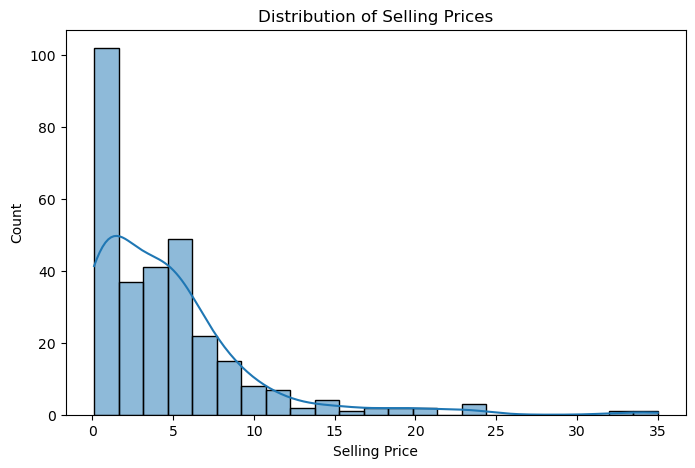

In [96]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Selling_Price"], kde=True)
plt.title("Distribution of Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Count")
plt.show()

## Price vs Fuel Type Box Plot

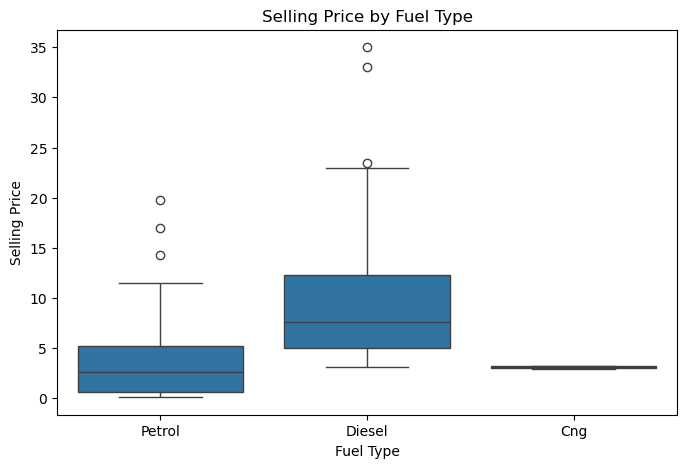

In [97]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Fuel_Type", y="Selling_Price", data=df)
plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.show()

## Price vs Car Age Scatter Plot

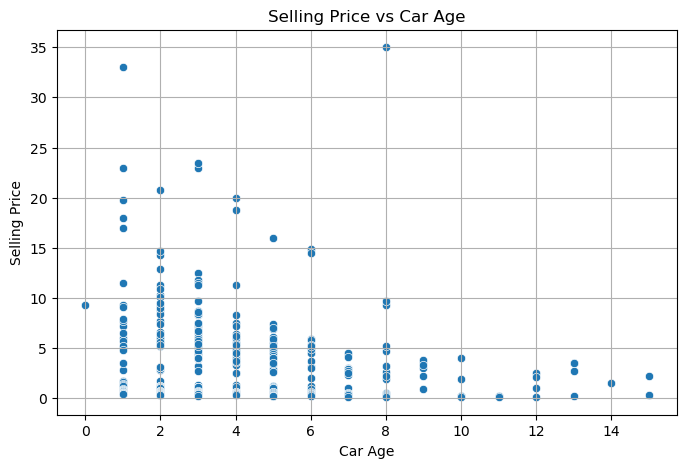

In [98]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Car_Age", y="Selling_Price", data=df)
plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.grid(True)
plt.show()

## Check Correlation

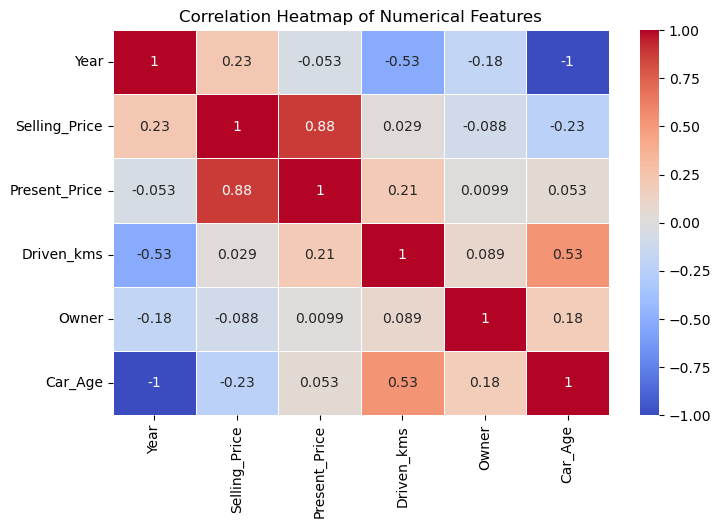

In [99]:
numeric_columns = ["Year", "Selling_Price", "Present_Price", "Driven_kms", "Owner", "Car_Age"]

plt.figure(figsize=(8, 5))
sns.heatmap(df[numeric_columns].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

## Data Preprocessing for Machine Learning

In [100]:
df = df.drop(["Car_Name", "Year"], axis=1)

df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age,Brand
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,4,ritz
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,5,sx4
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,1,ciaz
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,7,wagon
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,4,swift


## Encode Categorical Columns

In [101]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual,Brand_Activa,...,Brand_land,Brand_omni,Brand_ritz,Brand_s,Brand_swift,Brand_sx4,Brand_verna,Brand_vitara,Brand_wagon,Brand_xcent
0,3.35,5.59,27000,0,4,False,True,False,True,False,...,False,False,True,False,False,False,False,False,False,False
1,4.75,9.54,43000,0,5,True,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
2,7.25,9.85,6900,0,1,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,2.85,4.15,5200,0,7,False,True,False,True,False,...,False,False,False,False,False,False,False,False,True,False
4,4.60,6.87,42450,0,4,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False


## Check That All Columns Are Numeric

In [102]:
df.dtypes

Selling_Price              float64
Present_Price              float64
Driven_kms                   int64
Owner                        int64
Car_Age                      int64
Fuel_Type_Diesel              bool
Fuel_Type_Petrol              bool
Selling_type_Individual       bool
Transmission_Manual           bool
Brand_Activa                  bool
Brand_Bajaj                   bool
Brand_Hero                    bool
Brand_Honda                   bool
Brand_Hyosung                 bool
Brand_KTM                     bool
Brand_Mahindra                bool
Brand_Royal                   bool
Brand_Suzuki                  bool
Brand_TVS                     bool
Brand_UM                      bool
Brand_Yamaha                  bool
Brand_alto                    bool
Brand_amaze                   bool
Brand_baleno                  bool
Brand_brio                    bool
Brand_camry                   bool
Brand_ciaz                    bool
Brand_city                    bool
Brand_corolla       

In [103]:
df.select_dtypes(include="object").columns

Index([], dtype='object')

## Model Training

## Select Features and Target

In [104]:
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

## Split Data into Training and Testing

In [105]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train Linear Regression Model

In [106]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Make Predictions

In [107]:
lr_pred = lr_model.predict(X_test)

lr_pred

array([ 8.37832572,  7.20582637,  1.76321329,  6.72656135, 11.5136192 ,
        4.76600065,  8.68894547,  1.82550443, 13.32378051, -0.72160161,
        8.2713007 , -1.25591669, -0.55885538,  1.3643854 ,  4.46595775,
        4.92090911,  1.4663307 ,  1.35876732, 23.44994293,  0.49438653,
        0.58374082,  6.84407013,  5.8058132 ,  0.39564687,  5.78410932,
        9.24070299,  9.4204948 ,  1.23261312,  5.52056838,  5.47355357,
        4.00363474,  5.25436234,  5.79572538,  2.06438802,  2.11897518,
       10.99407461,  1.35919837, -9.66784816,  5.11526717, 10.7166652 ,
        6.0210772 , 10.4584625 ,  1.98153776,  0.86957718,  0.64303545,
       -2.43818539, 11.43474658,  3.899323  ,  4.39916726, -0.39578052,
        1.10944785,  0.58770354, 19.27050561, 12.0400413 ,  8.65498517,
        5.71239131,  3.67346678,  2.83346417, 11.42806311,  9.47798897])

## Evaluate Linear Regression

In [108]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression MAE:", lr_mae)
print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R2 Score:", lr_r2)

Linear Regression MAE: 1.807786967346581
Linear Regression RMSE: 3.395653839987743
Linear Regression R2 Score: 0.5526191096181178


## Actual vs Predicted Values

In [117]:
results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": lr_pred
})

results.head(10)

,Actual Price,Predicted Price
283,8.99,8.378326
267,8.35,7.205826
166,0.45,1.763213
9,7.45,6.726561
78,5.25,11.513619
280,5.25,4.766001
95,5.85,8.688945
111,1.15,1.825504
5,9.25,13.323781
175,0.38,-0.721602


## Visualize Actual vs Predicted Prices

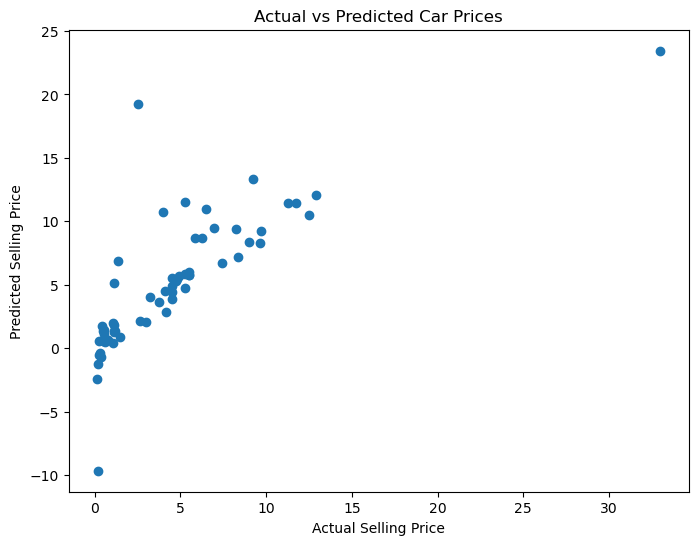

In [118]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, lr_pred)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

## Regression Line Plot

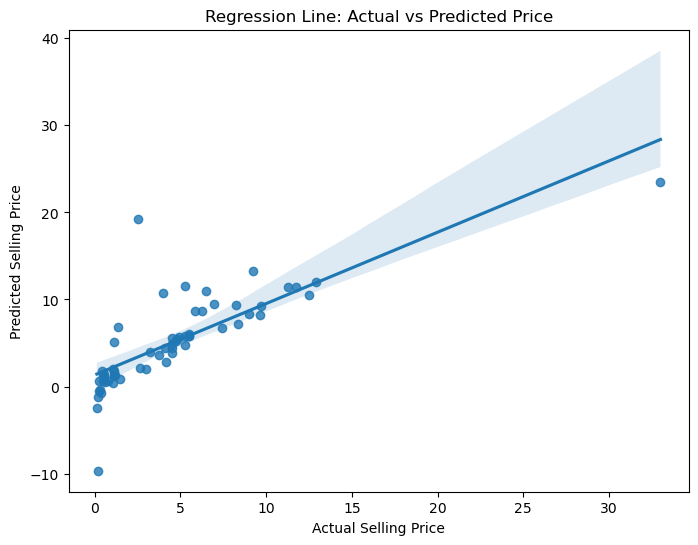

In [119]:
plt.figure(figsize=(8, 6))
sns.regplot(x=y_test, y=lr_pred)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Regression Line: Actual vs Predicted Price")
plt.show()

# Decision Tree Model

In [112]:
from sklearn.tree import DecisionTreeRegressor

## Create and Train the Model

In [113]:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


## Make Predictions

In [114]:
dt_pred = dt_model.predict(X_test)

dt_pred

array([ 7.25,  9.1 ,  0.45,  7.2 , 14.5 ,  5.3 ,  7.45,  1.2 ,  7.25,
        0.2 ,  9.25,  0.25,  0.27,  0.48,  4.75,  5.65,  0.6 ,  1.35,
       19.75,  0.55,  0.55,  2.9 ,  5.75,  1.95,  7.9 ,  8.65,  8.55,
        1.1 ,  4.5 ,  4.95,  4.  ,  3.95,  7.9 ,  2.85,  4.  ,  6.5 ,
        1.15,  0.1 ,  1.35, 14.5 ,  5.2 , 11.25,  0.72,  3.6 ,  0.55,
        0.2 , 11.25,  5.3 ,  4.4 ,  0.2 ,  0.65,  0.3 , 14.9 , 11.25,
        8.5 ,  8.25,  2.9 ,  3.45, 11.25,  7.05])

## Evaluate Decision Tree Model

In [115]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Mean Absolute Error:", dt_mae)
print("Decision Tree Mean Squared Error:", dt_mse)
print("Decision Tree Root Mean Squared Error:", dt_rmse)
print("Decision Tree R2 Score:", dt_r2)

Decision Tree Mean Absolute Error: 1.3685
Decision Tree Mean Squared Error: 9.733305000000001
Decision Tree Root Mean Squared Error: 3.1198245142956362
Decision Tree R2 Score: 0.6223487381582704


## Compare Actual vs Predicted Prices

In [120]:
dt_results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": dt_pred
})

dt_results.head(10)

,Actual Price,Predicted Price
283,8.99,7.25
267,8.35,9.10
166,0.45,0.45
9,7.45,7.20
78,5.25,14.50
280,5.25,5.30
95,5.85,7.45
111,1.15,1.20
5,9.25,7.25
175,0.38,0.20


## Visualize Actual vs Predicted Prices

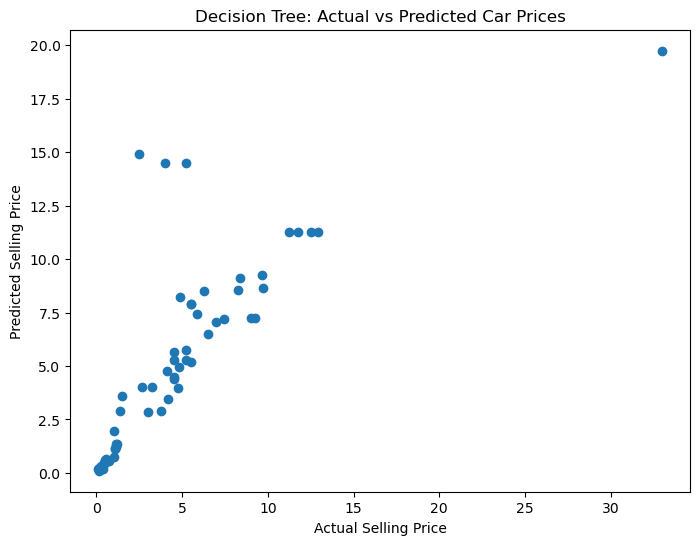

In [121]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, dt_pred)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Decision Tree: Actual vs Predicted Car Prices")
plt.show()

## Compare Linear Regression and Decision Tree

In [122]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree Regressor"],
    "MAE": [lr_mae, dt_mae],
    "RMSE": [lr_rmse, dt_rmse],
    "R2 Score": [lr_r2, dt_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.807787,3.395654,0.552619
1,Decision Tree Regressor,1.368500,3.119825,0.622349


## Visualize Model Comparison

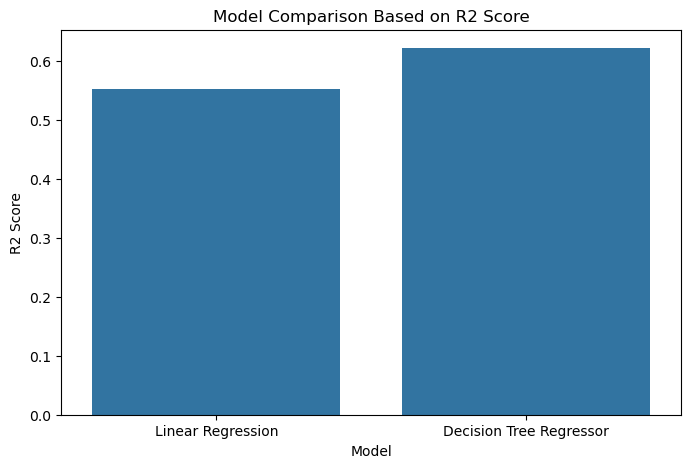

In [123]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="R2 Score", data=comparison)
plt.title("Model Comparison Based on R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.show()

## Actual vs Predicted Graph

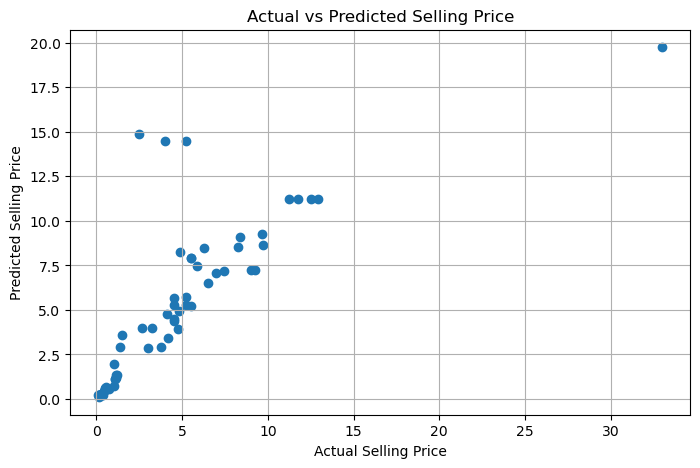

In [124]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, dt_pred)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.grid(True)
plt.show()

## Feature Importance

In [125]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
0,Present_Price,9.075968e-01
3,Car_Age,7.403877e-02
1,Driven_kms,1.101724e-02
27,Brand_corolla,4.098758e-03
26,Brand_city,1.458273e-03
7,Transmission_Manual,7.476715e-04
21,Brand_amaze,2.302741e-04
47,Brand_verna,2.051981e-04
23,Brand_brio,1.229367e-04
5,Fuel_Type_Petrol,1.102874e-04


## Feature Importance Chart

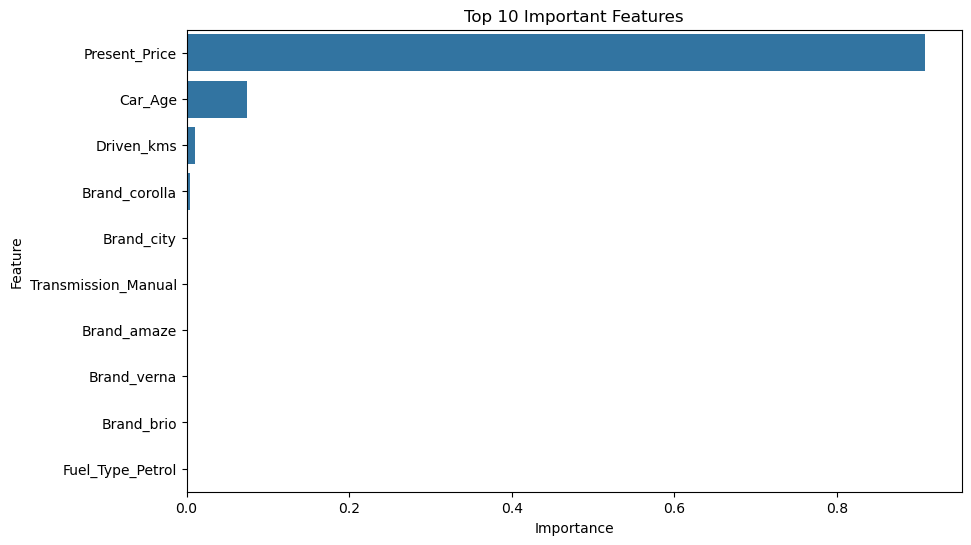

In [126]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance.head(10))
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Conclusion

In this project, I built a machine learning model to predict the selling price of used cars. The dataset was cleaned by checking missing values, removing duplicates, and standardizing categorical values.

I created a new feature called Car_Age from the Year column and extracted the Brand from the Car_Name column. Exploratory data analysis was performed using visualizations such as selling price distribution, price by fuel type, price vs car age, and correlation heatmap.

For model building, I trained two regression models: Linear Regression and Decision Tree Regressor. Both models were evaluated using MAE, RMSE, and R2 Score. The model with lower error values and higher R2 Score was considered the better-performing model.

This project helped me understand how machine learning regression models can be used for real-world car price prediction problems.